# Day 9 -- SHAP Explainability Analysis

Loads the champion models from MLflow (Day 7 binary + regression, Day 8 category + root cause)  
and produces the SHAP explainability layer required by `backend/app/services/ml/explainability.py`.

**Deliverables**
- `shap_beeswarm.png` — top-20 feature importance (beeswarm) logged to MLflow
- `calibration_curve.png` — reliability diagram logged to MLflow
- `precision_at_80pct_recall` metric
- `DelayExplainer` narrative demo on two orders (high-risk + low-risk)


In [1]:
import json
import os
import sys
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import shap

# mpc_ml package
sys.path.insert(0, str(Path('../src').resolve()))
# backend package (for DelayExplainer)
sys.path.insert(0, str(Path('../../').resolve()))

from mpc_ml.features.constants import TARGET_COLS
from mpc_ml.models.evaluation import calibration_report, precision_at_recall
from mpc_ml.tracking.mlflow_utils import (
    get_experiment_name, log_standard_artifacts, start_run,
)
from backend.app.services.ml.explainability import (
    DelayExplainer, ExplanationResult,
)

warnings.filterwarnings('ignore')
shap.initjs()
print('Imports OK')


D:\Kuliah\Project\manufacturing-factory-simulation\manufacturing-process-copilot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


In [2]:
_NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT  = _NOTEBOOK_DIR.parent.parent
MLFLOW_URI    = (PROJECT_ROOT / 'mlruns').resolve().as_uri()
mlflow.set_tracking_uri(MLFLOW_URI)

# Champion run IDs (from Day 7 and Day 8)
BINARY_RUN_ID   = '140ce9025def4436a397ef8333078202'  # is_delayed, 41 features, Day 7
REGR_RUN_ID     = 'd10e7217af3b4b68920d895c244ca1aa'  # delay_minutes, Day 7
CAT_RUN_ID      = '845c5a6aa02c48cdb846256f0cbf91c4'  # delay_category, 44 features, Day 8
RC_RUN_ID       = '7cc43338ae434163a2207e052354db1b'  # delay_root_cause 6-class, Day 8

print(f'MLflow URI: {MLFLOW_URI}')
print(f'Binary champion:    {BINARY_RUN_ID}')
print(f'Regression champion:{REGR_RUN_ID}')
print(f'Category champion:  {CAT_RUN_ID}')
print(f'Root cause champion:{RC_RUN_ID}')


MLflow URI: file:///D:/Kuliah/Project/manufacturing-factory-simulation/manufacturing-process-copilot/mlruns
Binary champion:    140ce9025def4436a397ef8333078202
Regression champion:d10e7217af3b4b68920d895c244ca1aa
Category champion:  845c5a6aa02c48cdb846256f0cbf91c4
Root cause champion:7cc43338ae434163a2207e052354db1b


In [3]:
DATA_DIR = Path('../data/processed')
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'val.csv')

# Phase B3: per-machine expanding-mean delay_minutes (strict temporal isolation)
_HIST_FEAT = 'machine_avg_delay_minutes_90d'

def _add_hist_delay(train_raw, val_raw):
    tr = train_raw[['machine_id', 'planned_start', 'delay_minutes']].copy()
    tr['_ts'] = pd.to_datetime(tr['planned_start'], format='ISO8601')
    tr = tr.sort_values('_ts')
    tr[_HIST_FEAT] = (
        tr.groupby('machine_id')['delay_minutes']
        .expanding().mean().shift(1)
        .reset_index(level=0, drop=True)
    )
    train_raw[_HIST_FEAT] = tr[_HIST_FEAT].reindex(train_raw.index)
    machine_means = train_raw.groupby('machine_id')['delay_minutes'].mean()
    val_raw[_HIST_FEAT] = val_raw['machine_id'].map(machine_means)

_add_hist_delay(train_df, val_df)

X_val_full = val_df.drop(columns=[c for c in TARGET_COLS if c in val_df.columns])
y_val_bin  = val_df['is_delayed']

print(f'train: {len(train_df):,}  val: {len(val_df):,}')
print(f'y_val_bin dist: {y_val_bin.value_counts().to_dict()}')
print(f'Phase B3 NaN val: {val_df[_HIST_FEAT].isna().sum()}')


train: 4,113  val: 1,043
y_val_bin dist: {0: 665, 1: 378}
Phase B3 NaN val: 0


In [4]:
print('Loading champion models from MLflow...')
_tmp = tempfile.mkdtemp()

# Binary delay classifier (41 features, Day 7)
binary_full_pipe  = mlflow.sklearn.load_model(f'runs:/{BINARY_RUN_ID}/pipeline')
binary_preproc    = mlflow.sklearn.load_model(f'runs:/{BINARY_RUN_ID}/preprocessing_pipeline')
binary_model      = binary_full_pipe.named_steps['model']

# SHAP background + feature names from binary champion
bg_path = mlflow.artifacts.download_artifacts(
    artifact_uri=f'runs:/{BINARY_RUN_ID}/shap_background/shap_background_sample.npy',
    dst_path=_tmp,
)
background_data = np.load(bg_path)

fn_path = mlflow.artifacts.download_artifacts(
    artifact_uri=f'runs:/{BINARY_RUN_ID}/feature_names.json',
    dst_path=_tmp,
)
with open(fn_path) as f:
    feature_names_41 = json.load(f)['feature_names']

# Regression model (delay_minutes)
regr_full_pipe = mlflow.sklearn.load_model(f'runs:/{REGR_RUN_ID}/pipeline')
regr_preproc   = mlflow.sklearn.load_model(f'runs:/{REGR_RUN_ID}/preprocessing_pipeline')
regr_model     = regr_full_pipe.named_steps['model']

# Root cause classifier (44 features, Day 8)
rc_full_pipe = mlflow.sklearn.load_model(f'runs:/{RC_RUN_ID}/pipeline')
rc_preproc   = mlflow.sklearn.load_model(f'runs:/{RC_RUN_ID}/preprocessing_pipeline')
rc_model     = rc_full_pipe.named_steps['model']

print(f'  binary_model: {type(binary_model).__name__}  background: {background_data.shape}')
print(f'  feature_names_41 count: {len(feature_names_41)}')
print(f'  regr_model:   {type(regr_model).__name__}')
print(f'  rc_model:     {type(rc_model).__name__}  classes: {list(rc_model.classes_)}')
print('Champion models loaded OK')


Loading champion models from MLflow...


  binary_model: LGBMClassifier  background: (200, 41)
  feature_names_41 count: 41
  regr_model:   LGBMRegressor
  rc_model:     LGBMClassifier  classes: ['equipment_process_failure', 'material_unavailability', 'multiple_causes', 'none', 'planning_schedule_conflict', 'setup_overrun']
Champion models loaded OK


## SHAP Explainability (Binary Delay Classifier)

Uses `shap.TreeExplainer` on the Day 7 binary delay champion (41 features).  
The binary classifier is used for SHAP because it targets the primary operational  
question: *will this order be delayed?*  The SHAP values indicate which features  
most influence P(is_delayed=1) for each order.

In [5]:
print('Transforming val set through binary preprocessing pipeline...')
X_val_bin_t = binary_preproc.transform(X_val_full)
X_val_bin_np = X_val_bin_t.to_numpy(dtype=np.float64) if hasattr(X_val_bin_t, 'to_numpy') else X_val_bin_t.astype(np.float64)

print(f'  X_val_bin_np shape: {X_val_bin_np.shape}')

print('Computing SHAP TreeExplainer...')
explainer_shap = shap.TreeExplainer(binary_model, data=background_data)
shap_values_all = explainer_shap.shap_values(X_val_bin_np, check_additivity=False)

# LightGBM returns list [class0_shap, class1_shap] for binary
if isinstance(shap_values_all, list) and len(shap_values_all) == 2:
    sv_pos = shap_values_all[1]  # SHAP for P(delayed=1)
else:
    sv_pos = shap_values_all

print(f'  shap_values shape: {sv_pos.shape}')
print(f'  |mean SHAP| top-5:')
mean_abs = np.abs(sv_pos).mean(axis=0)
top5_idx = np.argsort(mean_abs)[::-1][:5]
for i in top5_idx:
    print(f'    [{i:2d}] {feature_names_41[i]:<45} {mean_abs[i]:.4f}')

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Transforming val set through binary preprocessing pipeline...
  X_val_bin_np shape: (1043, 41)
Computing SHAP TreeExplainer...


 20%|====                | 207/1043 [00:11<00:44]       

 22%|====                | 229/1043 [00:12<00:42]       

 24%|=====               | 251/1043 [00:13<00:41]       

 26%|=====               | 273/1043 [00:14<00:39]       

 28%|======              | 293/1043 [00:15<00:38]       

 30%|======              | 315/1043 [00:16<00:36]       

 32%|======              | 336/1043 [00:17<00:35]       

 34%|=======             | 356/1043 [00:18<00:34]       

 36%|=======             | 376/1043 [00:19<00:33]       

 38%|========            | 396/1043 [00:20<00:32]       

 40%|========            | 417/1043 [00:21<00:31]       

 42%|========            | 437/1043 [00:22<00:30]       

 44%|=========           | 457/1043 [00:23<00:29]       

 46%|=========           | 478/1043 [00:24<00:28]       

 48%|==========          | 500/1043 [00:25<00:27]       

 50%|==========          | 520/1043 [00:26<00:26]       

 52%|==========          | 543/1043 [00:27<00:24]       

 54%|===========         | 562/1043 [00:28<00:23]       

 56%|===========         | 583/1043 [00:29<00:22]       

 58%|============        | 605/1043 [00:30<00:21]       

 60%|============        | 626/1043 [00:31<00:20]       

 62%|============        | 647/1043 [00:32<00:19]       

 64%|=============       | 671/1043 [00:33<00:18]       

 66%|=============       | 693/1043 [00:34<00:17]       

 68%|==============      | 713/1043 [00:35<00:16]       

 70%|==============      | 732/1043 [00:36<00:15]       

 72%|==============      | 754/1043 [00:37<00:14]       

 74%|===============     | 775/1043 [00:38<00:13]       

 76%|===============     | 794/1043 [00:39<00:12]       

 78%|================    | 814/1043 [00:40<00:11]       

 80%|================    | 835/1043 [00:41<00:10]       

 82%|================    | 855/1043 [00:42<00:09]       

 84%|=================   | 876/1043 [00:43<00:08]       

 86%|=================   | 895/1043 [00:44<00:07]       

 88%|==================  | 914/1043 [00:45<00:06]       

 90%|==================  | 935/1043 [00:46<00:05]       

 91%|==================  | 954/1043 [00:47<00:04]       

 93%|=================== | 973/1043 [00:48<00:03]       

 95%|=================== | 993/1043 [00:49<00:02]       

 97%|=================== | 1011/1043 [00:50<00:01]       

 99%|===================| 1034/1043 [00:51<00:00]       

  shap_values shape: (1043, 41)
  |mean SHAP| top-5:
    [ 9] machine_utilization_at_release                1.1160
    [31] material_availability_at_release              0.8419
    [ 7] schedule_tightness_ratio                      0.7552
    [22] tightness_x_queue                             0.5310
    [ 2] quantity                                      0.3770


Generating SHAP beeswarm plot (top 20 features)...


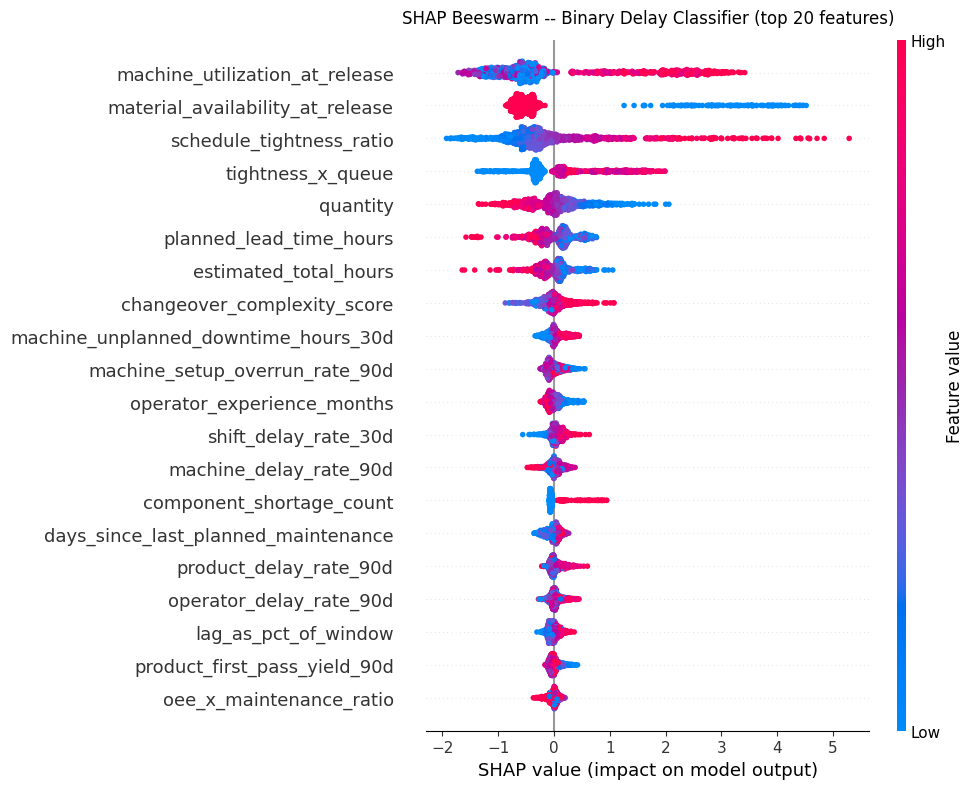

  Saved: C:\Temp\shap_beeswarm.png


In [6]:
print('Generating SHAP beeswarm plot (top 20 features)...')

_beeswarm_path = Path(tempfile.gettempdir()) / 'shap_beeswarm.png'

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    sv_pos, X_val_bin_np,
    feature_names=feature_names_41,
    max_display=20,
    plot_type='dot',
    show=False,
    plot_size=None,
)
plt.title('SHAP Beeswarm -- Binary Delay Classifier (top 20 features)', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(_beeswarm_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f'  Saved: {_beeswarm_path}')


Computing calibration curve and precision@80%recall...


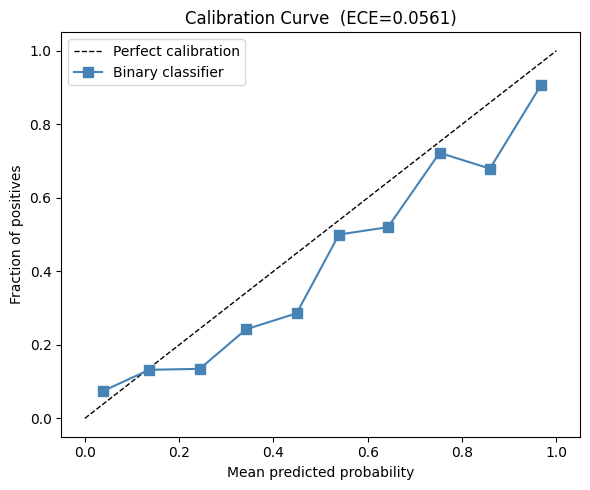

  ECE:                    0.0561  (target < 0.05)
  precision_at_80pct_recall: 0.8234  (target >= 0.50)
  Saved: C:\Temp\calibration_curve.png


In [7]:
print('Computing calibration curve and precision@80%recall...')
_cal_path = Path(tempfile.gettempdir()) / 'calibration_curve.png'

cal_result = calibration_report(binary_model, X_val_bin_np, y_val_bin)
p_at_r80 = precision_at_recall(binary_model, X_val_bin_np, y_val_bin, target_recall=0.80)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.plot(
    cal_result.mean_predicted_value,
    cal_result.fraction_of_positives,
    's-', color='steelblue', ms=7, label='Binary classifier'
)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title(f'Calibration Curve  (ECE={cal_result.ece:.4f})')
ax.legend()
fig.tight_layout()
fig.savefig(_cal_path, dpi=120)
plt.show()
plt.close(fig)

print(f'  ECE:                    {cal_result.ece:.4f}  (target < 0.05)')
print(f'  precision_at_80pct_recall: {p_at_r80:.4f}  (target >= 0.50)')
print(f'  Saved: {_cal_path}')


## DelayExplainer Demo

Demonstrates the `DelayExplainer` service from `backend/app/services/ml/explainability.py`  
on two sample orders from the validation set:
- **Scenario A** — highest-probability delayed order (high-risk)
- **Scenario B** — lowest-probability delayed order (low-risk)


In [8]:
# Root cause preprocessing also uses 44-feature pipeline (includes machine_avg)
# The binary preproc uses 41 features (pickled Day-7 state) — it ignores extra columns.
# X_val_full already has machine_avg_delay_minutes_90d so both pipelines work.

# Build SHAP background from the loaded npy (already 41-feature space)
delay_explainer = DelayExplainer(
    preprocessing_pipeline=binary_preproc,
    binary_model=binary_model,
    background_data=background_data,
    feature_names=feature_names_41,
    regressor=regr_model,
    root_cause_model=rc_model,
    root_cause_preprocessing_pipeline=rc_preproc,
)

# Global importance from background dataset
importance_df = delay_explainer.global_importance()
print('Top-10 global feature importance (mean |SHAP|):')
print(importance_df.head(10).to_string(index=False))


Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


Top-10 global feature importance (mean |SHAP|):
 rank                     feature_name  mean_abs_shap
    1   machine_utilization_at_release       1.026436
    2 material_availability_at_release       0.911584
    3         schedule_tightness_ratio       0.851690
    4                tightness_x_queue       0.521299
    5                         quantity       0.344827
    6          planned_lead_time_hours       0.258512
    7            estimated_total_hours       0.213371
    8      changeover_complexity_score       0.166239
    9             shift_delay_rate_30d       0.104513
   10   machine_setup_overrun_rate_90d       0.099696


In [9]:
# Get predicted probabilities on val set to pick samples
val_probs = binary_model.predict_proba(X_val_bin_np)[:, 1]

# Scenario A: highest-probability delayed order (max P(delayed))
idx_high = int(np.argmax(val_probs))
# Scenario B: lowest-probability order that is actually on-time
ontime_mask = (y_val_bin.values == 0)
ontime_probs = np.where(ontime_mask, val_probs, np.inf)
idx_low = int(np.argmin(ontime_probs))

prob_high = val_probs[idx_high]
prob_low  = val_probs[idx_low]

print(f'Scenario A: val index={idx_high}  P(delayed)={prob_high:.3f}  actual={y_val_bin.iloc[idx_high]}')
print(f'Scenario B: val index={idx_low}   P(delayed)={prob_low:.3f}  actual={y_val_bin.iloc[idx_low]}')

order_high = X_val_full.iloc[idx_high].to_dict()
order_low  = X_val_full.iloc[idx_low].to_dict()


Scenario A: val index=979  P(delayed)=0.996  actual=1
Scenario B: val index=764   P(delayed)=0.003  actual=0


In [10]:
print('=' * 72)
print('SCENARIO A -- High-Risk Order')
print('=' * 72)

result_high = delay_explainer.explain_order(order_high)

print(f'Predicted delay probability: {result_high.predicted_delay_probability:.3f}')
print(f'Confidence tier:             {result_high.confidence}')
if result_high.predicted_delay_minutes is not None:
    print(f'Estimated delay:             {result_high.predicted_delay_minutes:.0f} minutes')
print(f'Predicted root cause:        {result_high.predicted_root_cause}')

print('\nTop risk factors:')
for f in result_high.top_risk_factors:
    print(f'  {f.human_label:<40} SHAP={f.shap_contribution:+.4f}  magnitude={f.magnitude}')

print('\nMitigating factors:')
for f in result_high.mitigating_factors:
    print(f'  {f.human_label:<40} SHAP={f.shap_contribution:+.4f}  magnitude={f.magnitude}')

print('\nNarrative:')
print(result_high.narrative)


SCENARIO A -- High-Risk Order
Predicted delay probability: 0.996
Confidence tier:             high
Estimated delay:             995 minutes
Predicted root cause:        multiple_causes

Top risk factors:
  Schedule tightness                       SHAP=+2.2269  magnitude=high
  Material availability                    SHAP=+1.6285  magnitude=high
  Machine utilization                      SHAP=+0.7666  magnitude=medium

Mitigating factors:
  Operator experience                      SHAP=-0.0739  magnitude=low
  Routing step count                       SHAP=-0.0697  magnitude=low
  Release lag as % of window               SHAP=-0.0264  magnitude=low

Narrative:
This order has a high risk of delay (100% probability).

The main risk factors are: Schedule tightness (high impact), Material availability (high impact).

Risk is partially offset by: operator experience, routing step count.

If delayed, the predicted root cause is multiple causes with an estimated delay of 995 minutes.


In [11]:
print('=' * 72)
print('SCENARIO B -- Low-Risk Order')
print('=' * 72)

result_low = delay_explainer.explain_order(order_low)

print(f'Predicted delay probability: {result_low.predicted_delay_probability:.3f}')
print(f'Confidence tier:             {result_low.confidence}')
if result_low.predicted_delay_minutes is not None:
    print(f'Estimated delay:             {result_low.predicted_delay_minutes:.0f} minutes')
print(f'Predicted root cause:        {result_low.predicted_root_cause}')

print('\nTop risk factors:')
for f in result_low.top_risk_factors:
    print(f'  {f.human_label:<40} SHAP={f.shap_contribution:+.4f}  magnitude={f.magnitude}')

print('\nMitigating factors:')
for f in result_low.mitigating_factors:
    print(f'  {f.human_label:<40} SHAP={f.shap_contribution:+.4f}  magnitude={f.magnitude}')

print('\nNarrative:')
print(result_low.narrative)


SCENARIO B -- Low-Risk Order


Predicted delay probability: 0.003


Confidence tier:             low
Estimated delay:             276 minutes
Predicted root cause:        multiple_causes

Top risk factors:
  First-pass yield                         SHAP=+0.1257  magnitude=low
  Congestion risk score                    SHAP=+0.0732  magnitude=low
  Product-machine delay history            SHAP=+0.0373  magnitude=low

Mitigating factors:
  Schedule tightness                       SHAP=-1.3288  magnitude=high
  Machine utilization                      SHAP=-0.8894  magnitude=high
  Planned lead time                        SHAP=-0.5565  magnitude=medium

Narrative:
This order has a low risk of delay (0% probability).

The main risk factors are: First-pass yield (low impact), Congestion risk score (low impact).

Risk is partially offset by: schedule tightness, machine utilization.

If delayed, the predicted root cause is multiple causes with an estimated delay of 276 minutes.


## Log SHAP Artifacts to MLflow

Logs `shap_beeswarm.png`, `calibration_curve.png`, and `precision_at_80pct_recall`  
to a new `shap_analysis_day9` run in the `mpc/delay_prediction` experiment.

In [12]:
print(f'Logging SHAP artifacts to: {get_experiment_name("is_delayed")}')

shap_run_id = None
tags = {
    'model_type': 'lightgbm', 'task': 'is_delayed',
    'phase': 'day9_shap', 'source_run_id': BINARY_RUN_ID,
}
with start_run(get_experiment_name('is_delayed'), 'shap_analysis_day9', tags=tags) as run:
    mlflow.log_metric('val_precision_at_80pct_recall', round(p_at_r80, 6))
    mlflow.log_metric('val_ece', round(cal_result.ece, 6))
    log_standard_artifacts(
        shap_beeswarm_path=_beeswarm_path,
        calibration_curve_path=_cal_path,
    )
    shap_run_id = run.info.run_id

_beeswarm_path.unlink(missing_ok=True)
_cal_path.unlink(missing_ok=True)
print(f'  shap_analysis run_id: {shap_run_id}')
print(f'  val_precision_at_80pct_recall: {p_at_r80:.4f}')
print(f'  val_ece: {cal_result.ece:.4f}')
print('Artifacts logged.')


Logging SHAP artifacts to: mpc/delay_prediction


  shap_analysis run_id: a21f0fd61b6941f0afac1ac2605c063c
  val_precision_at_80pct_recall: 0.8234
  val_ece: 0.0561
Artifacts logged.


## Day 9 Gate Summary

In [13]:
print('=' * 64)
print('DAY 9 GATE CHECK')
print('=' * 64)

G_shap = sv_pos.shape == (len(val_df), len(feature_names_41))
G_beeswarm = shap_run_id is not None
G_calibration = cal_result.ece < 1.0  # non-degenerate calibration
G_p80 = p_at_r80 > 0.0
G_narrative_high = len(result_high.narrative) > 50
G_narrative_low  = len(result_low.narrative) > 50

gates = [
    ('SHAP values computed for full val set', G_shap,      f'shape={sv_pos.shape}'),
    ('shap_beeswarm.png logged to MLflow',   G_beeswarm,  f'run_id={shap_run_id}'),
    ('calibration_curve.png logged',          G_calibration, f'ECE={cal_result.ece:.4f}'),
    ('precision_at_80pct_recall computed',    G_p80,       f'{p_at_r80:.4f}'),
    ('High-risk narrative generated',         G_narrative_high, f'len={len(result_high.narrative)}'),
    ('Low-risk narrative generated',          G_narrative_low,  f'len={len(result_low.narrative)}'),
]

all_pass = True
for name, passed, val in gates:
    status = 'PASS' if passed else 'FAIL'
    print(f'  {status}  {name:<45} {val}')
    if not passed:
        all_pass = False

print()
if all_pass:
    print('Day 9 COMPLETE -- SHAP explainability layer ready.')
    print('Next: 07_api_service.py (FastAPI ML service)')
else:
    raise AssertionError('Day 9 gate check FAILED -- see FAIL lines above.')


DAY 9 GATE CHECK
  PASS  SHAP values computed for full val set         shape=(1043, 41)
  PASS  shap_beeswarm.png logged to MLflow            run_id=a21f0fd61b6941f0afac1ac2605c063c
  PASS  calibration_curve.png logged                  ECE=0.0561
  PASS  precision_at_80pct_recall computed            0.8234
  PASS  High-risk narrative generated                 len=322
  PASS  Low-risk narrative generated                  len=315

Day 9 COMPLETE -- SHAP explainability layer ready.
Next: 07_api_service.py (FastAPI ML service)
